# Project 1: Crime in Austin, Texas (2015)

**Course:** CS 5830 &mdash; Data Science
**Dataset:** Austin Police Department reported-crime records, [Austin Crime dataset on Kaggle](https://www.kaggle.com/datasets/jboysen/austin-crime) (`austin_crime.csv`). 

This notebook explores what drives *whether a reported crime in Austin is solved* and *when crimes are reported*, using the 2015 records.



In [13]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
pd.set_option("display.max_columns", 50)

DATA_PATH = "austin_crime.csv"
os.makedirs("figures", exist_ok=True) 


## 1. Data preparation

The file `austin_crime.csv` has about 159,000 lines, but only about 73,500 of them are real crime records (2014 and 2015). The rest are address-only fragments in which every other column is empty (the original export split each record over two lines). We:

1. read every column as text so nothing is silently mis-typed,
2. drop the address-only fragments (rows without a `unique_key`),
3. keep **2015** only: the 2014 rows use a different, finer-grained set of offense labels (e.g. `Theft: BOV`, `Agg Assault` vs `Aggravated Assault`), which would make category comparisons inconsistent,
4. convert dates and numbers to proper types, and
5. keep the three real values of `clearance_status` (`Not cleared`, `Cleared by Arrest`, `Cleared by Exception`); a small number of 2015 rows have no status and are excluded from clearance analyses only.

In [14]:
raw = pd.read_csv(DATA_PATH, dtype=str)
print("Raw lines:", len(raw))

df = raw[raw["unique_key"].notna()].copy()         
print("Real crime records (2014+2015):", len(df))

df = df[df["year"] == "2015.0"].copy()
df["report_date"] = pd.to_datetime(df["timestamp"])
df["clearance_date"] = pd.to_datetime(df["clearance_date"])
for c in ["census_tract", "council_district_code", "x_coordinate", "y_coordinate"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["zipcode"] = pd.to_numeric(df["zipcode"], errors="coerce").astype("Int64")
df["cleared"] = df["clearance_status"].isin(["Cleared by Arrest", "Cleared by Exception"])
df = df.drop(columns=["latitude", "longitude", "location", "timestamp", "year"])

print("2015 records:", len(df))
df.head(3)

Raw lines: 159464
Real crime records (2014+2015): 73544
2015 records: 38573


,address,census_tract,clearance_date,clearance_status,council_district_code,description,district,location_description,primary_type,unique_key,x_coordinate,y_coordinate,zipcode,report_date,cleared
0,2620 RIO GRANDE ST Austin TX 78705,6.03,2015-12-14,Not cleared,9.0,THEFT,B,2620 RIO GRANDE ST,Theft,20155054365.0,3113531.0,10079579.0,78705,2015-12-13,False
1,9500 S IH 35 SVRD SB Austin TX 78748,24.21,2015-09-14,Cleared by Arrest,5.0,THEFT BY SHOPLIFTING,F,9500 S IH 35 SVRD SB,Theft,20152461290.0,3099459.0,10032098.0,78748,2015-09-03,True
5,710 E BEN WHITE BLVD EB Austin TX 78745,24.03,2015-01-07,Cleared by Arrest,3.0,THEFT BY SHOPLIFTING,D,710 E BEN WHITE BLVD EB,Theft,201520863.0,3110518.0,10052730.0,78745,2015-01-02,True


## 2. Dataset overview and data-quality caveats

The cleaned dataset holds one row per reported crime in Austin in 2015, with: offense description and category (`primary_type`), report date, address, police district, council district, ZIP code, census tract, X/Y coordinates, and `clearance_status` / `clearance_date`.

**Missing data.** A small share of records lack a clearance status, district or ZIP code. These are dropped only from the analyses that need those fields. 


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38573 entries, 0 to 159460
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   address                38573 non-null  object        
 1   census_tract           38414 non-null  float64       
 2   clearance_date         36649 non-null  datetime64[ns]
 3   clearance_status       36649 non-null  object        
 4   council_district_code  38401 non-null  float64       
 5   description            38573 non-null  object        
 6   district               38573 non-null  object        
 7   location_description   38092 non-null  object        
 8   primary_type           38573 non-null  object        
 9   unique_key             38573 non-null  object        
 10  x_coordinate           37981 non-null  float64       
 11  y_coordinate           37981 non-null  float64       
 12  zipcode                38414 non-null  Int64         
 13  repor

## 3. Descriptive statistics

Total reported crimes (2015): 38,573
clearance_status
Not cleared             30462
Cleared by Arrest        5245
NaN                      1924
Cleared by Exception      942
Name: count, dtype: int64

clearance_status
Not cleared             79.0
Cleared by Arrest       13.6
NaN                      5.0
Cleared by Exception     2.4
Name: proportion, dtype: float64


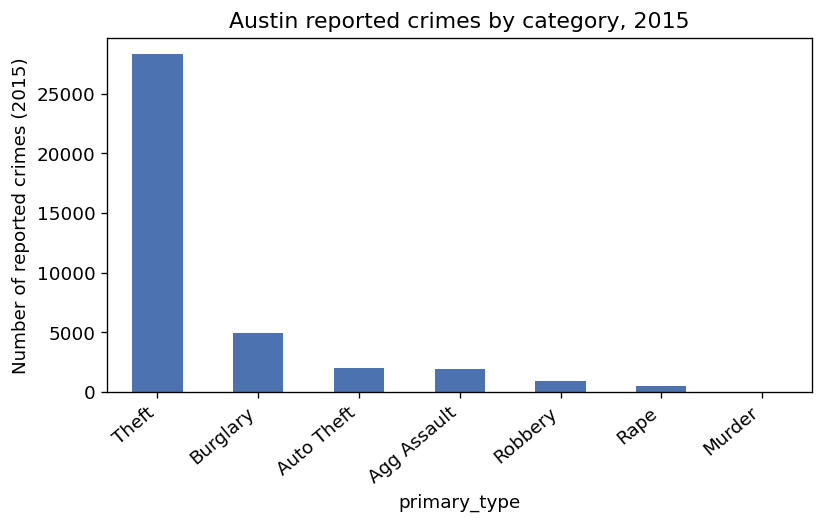

In [15]:
print(f"Total reported crimes (2015): {len(df):,}")
print(df["clearance_status"].value_counts(dropna=False))
print()
print((df["clearance_status"].value_counts(normalize=True, dropna=False) * 100).round(1))

type_counts = df["primary_type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4.5))
type_counts.plot(kind="bar", color="#4C72B0", ax=ax)
ax.set_ylabel("Number of reported crimes (2015)")
ax.set_title("Austin reported crimes by category, 2015")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
fig.savefig("figures/by_type.png", dpi=150)
plt.show()

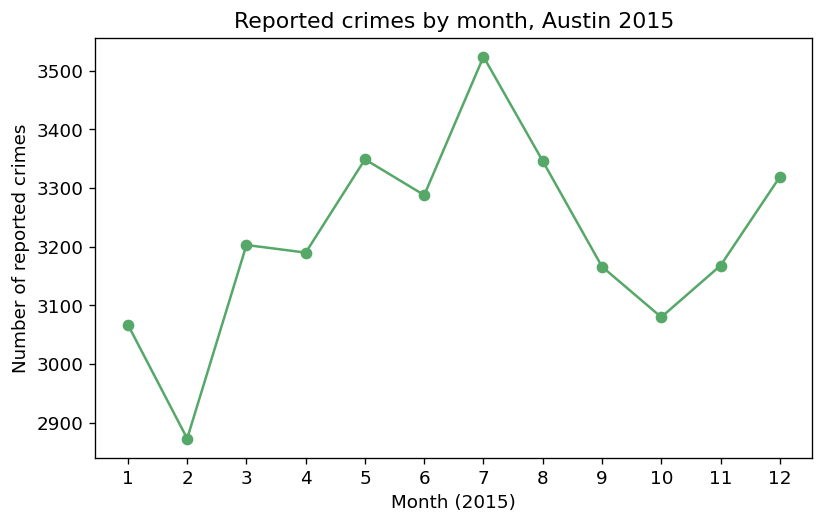

Mean crimes/month: 3214.4   Std dev: 167.7


In [5]:
df["month"] = df["report_date"].dt.month
monthly = df.groupby("month").size()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(monthly.index, monthly.values, marker="o", color="#55A868")
ax.set_xlabel("Month (2015)")
ax.set_ylabel("Number of reported crimes")
ax.set_title("Reported crimes by month, Austin 2015")
ax.set_xticks(range(1, 13))
plt.tight_layout()
fig.savefig("figures/by_month.png", dpi=150)
plt.show()

print(f"Mean crimes/month: {monthly.mean():.1f}   Std dev: {monthly.std():.1f}")

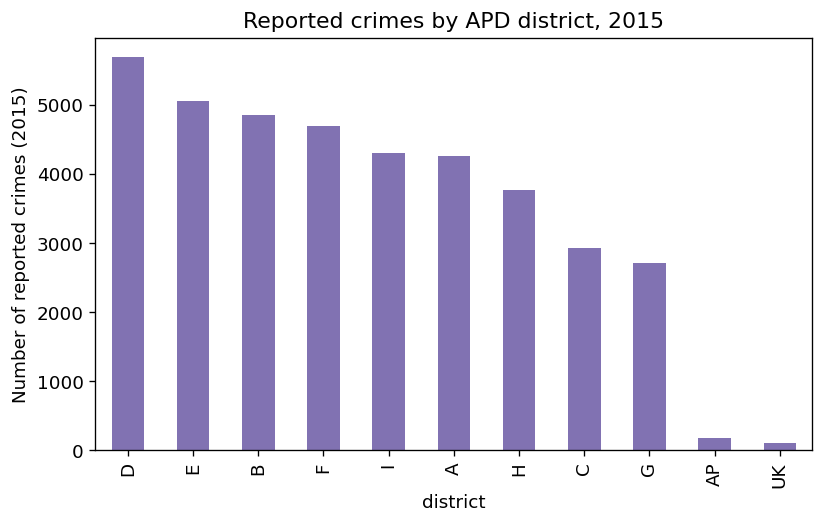

In [6]:
by_district = (df[df["district"].notna()].groupby("district")
               .agg(crimes=("cleared", "size")).sort_values("crimes", ascending=False))
fig, ax = plt.subplots(figsize=(7, 4.5))
by_district["crimes"].plot(kind="bar", color="#8172B2", ax=ax)
ax.set_ylabel("Number of reported crimes (2015)")
ax.set_title("Reported crimes by APD district, 2015")
plt.tight_layout()
fig.savefig("figures/by_district.png", dpi=150)
plt.show()

## 4. Statistical analyses

Clearance analyses use the records with a known `clearance_status`; a case counts as **cleared** if it was cleared by arrest or by exception.

In [16]:
cl = df[df["clearance_status"].notna()].copy()
print(f"Records with known clearance status: {len(cl):,}  (overall clearance rate {cl['cleared'].mean():.3f})")

Records with known clearance status: 36,649  (overall clearance rate 0.169)


### 4.1 Chi-square test of independence: crime type vs. clearance

**Hypothesis:** the chance a case is cleared depends on the type of crime (e.g. violent crimes are cleared more often than property crimes). Both variables are categorical, so a chi-square test of independence is appropriate; Cram&eacute;r's V gives the effect size.

chi2 = 3645.8, dof = 6, p = 0, Cramer's V = 0.315


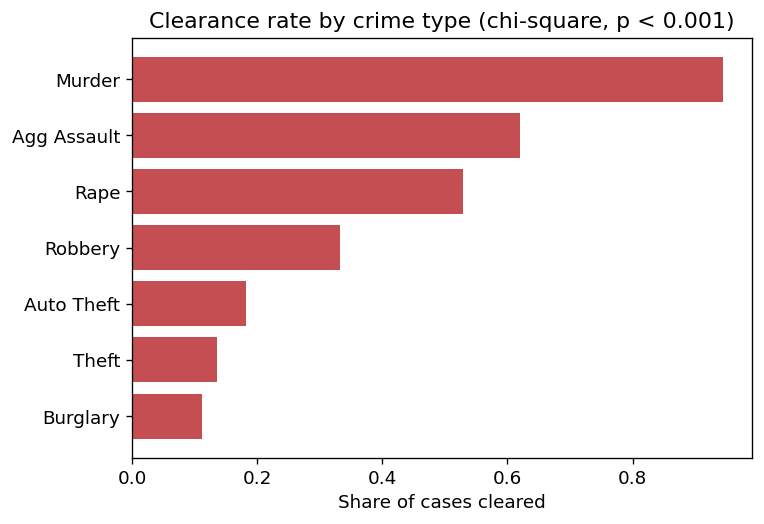

primary_type
Burglary       0.112
Theft          0.135
Auto Theft     0.182
Robbery        0.333
Rape           0.529
Agg Assault    0.620
Murder         0.944
Name: cleared, dtype: float64


In [17]:
ct = pd.crosstab(cl["primary_type"], cl["cleared"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"chi2 = {chi2:.1f}, dof = {dof}, p = {p_chi:.3g}, Cramer's V = {cramers_v:.3f}")

rate = cl.groupby("primary_type")["cleared"].mean().sort_values()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh(rate.index, rate.values, color="#C44E52")
ax.set_xlabel("Share of cases cleared")
ax.set_title(f"Clearance rate by crime type (chi-square, p < 0.001)")
plt.tight_layout()
fig.savefig("figures/clear_by_type.png", dpi=150)
plt.show()
print(rate.round(3))

**Result:** &chi;&sup2; = 3,646 (6 dof), p < 0.001, Cram&eacute;r's V = 0.32 (n = 36,649). Clearance depends strongly on crime type: murder is cleared 94% of the time and aggravated assault 62%, while burglary (11%) and theft (14%) are rarely solved. Violent crimes have identifiable victims and witnesses and get far more investigative effort; property crimes usually have neither. A V of 0.32 is a medium-to-large effect, the strongest relationship we found in this dataset.

### 4.2 Chi-square test: police district vs. clearance

**Hypothesis:** clearance rates differ across APD patrol districts. We keep the nine lettered patrol districts A&ndash;I (excluding `AP` airport and `UK` unknown).

chi2 = 237.0, dof = 8, p = 9.72e-47, Cramer's V = 0.081


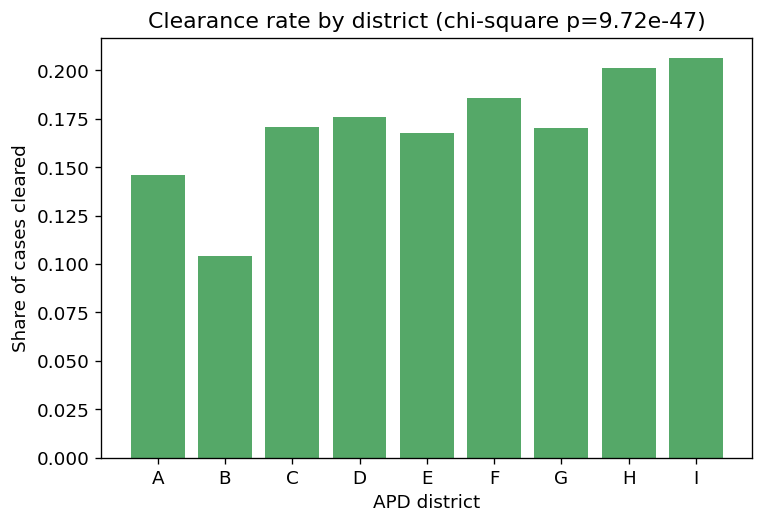

district
A    0.146
B    0.104
C    0.170
D    0.176
E    0.168
F    0.186
G    0.170
H    0.201
I    0.207
Name: cleared, dtype: float64


In [18]:
dist = cl[cl["district"].isin(list("ABCDEFGHI"))]
ct2 = pd.crosstab(dist["district"], dist["cleared"])
chi2b, p_b, dof_b, _ = stats.chi2_contingency(ct2)
v2 = np.sqrt(chi2b / (ct2.values.sum() * (min(ct2.shape) - 1)))
print(f"chi2 = {chi2b:.1f}, dof = {dof_b}, p = {p_b:.3g}, Cramer's V = {v2:.3f}")

rate_d = dist.groupby("district")["cleared"].mean()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(rate_d.index, rate_d.values, color="#55A868")
ax.set_ylabel("Share of cases cleared")
ax.set_xlabel("APD district")
ax.set_title(f"Clearance rate by district (chi-square p={p_b:.3g})")
plt.tight_layout()
fig.savefig("figures/clear_by_district.png", dpi=150)
plt.show()
print(rate_d.round(3))

**Result:** &chi;&sup2; = 237 (8 dof), p < 0.001, Cram&eacute;r's V = 0.08. The difference is statistically significant, but with ~36,000 cases almost any difference is, and the effect is small: clearance rates run from about 10% (district B) to 21% (district I). So this does not show that some districts' police perform better; that would require controlling for crime type.

### 4.3 Mann-Whitney U test: time to clearance, arrest vs. exception

**Hypothesis:** cases cleared by arrest are resolved on a different timeline than cases cleared by exception. Days between the report date and `clearance_date` are strongly right-skewed (most cases close within weeks, a few take months), so we use the non-parametric Mann-Whitney U test rather than a t-test.

Mann-Whitney U = 1414207.5, p = 1.24e-97
Arrest    (n=5245): median=5 days, mean=17.3
Exception (n=942): median=21 days, mean=38.0


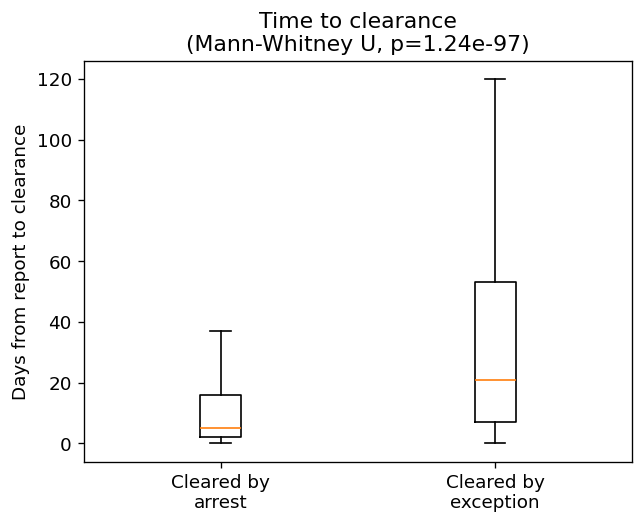

In [10]:
done = cl[cl["cleared"]].copy()
done["days_to_clear"] = (done["clearance_date"] - done["report_date"]).dt.days
done = done[done["days_to_clear"] >= 0]
arrest = done.loc[done["clearance_status"] == "Cleared by Arrest", "days_to_clear"]
exception = done.loc[done["clearance_status"] == "Cleared by Exception", "days_to_clear"]

u_stat, p_u = stats.mannwhitneyu(arrest, exception, alternative="two-sided")
print(f"Mann-Whitney U = {u_stat:.1f}, p = {p_u:.3g}")
print(f"Arrest    (n={len(arrest)}): median={arrest.median():.0f} days, mean={arrest.mean():.1f}")
print(f"Exception (n={len(exception)}): median={exception.median():.0f} days, mean={exception.mean():.1f}")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.boxplot([arrest, exception], tick_labels=["Cleared by\narrest", "Cleared by\nexception"], showfliers=False)
ax.set_ylabel("Days from report to clearance")
ax.set_title(f"Time to clearance\n(Mann-Whitney U, p={p_u:.3g})")
plt.tight_layout()
fig.savefig("figures/days_to_clear.png", dpi=150)
plt.show()

**Result:** U = 1,414,208, p < 0.001. Cases cleared by arrest are recorded a median of 5 days after the report (mean 17.3), versus a median of 21 days (mean 38.0) for cases cleared by exception, so arrests come much faster. This is consistent with arrests happening when a suspect is identified quickly, while exceptional clearances (e.g. victim declines to prosecute) take longer to be closed out. `clearance_date` is ambiguous (see Section 2), so this is best read as the time until the status was recorded.

### 4.4 Welch's t-test: weekday vs. weekend daily crime counts

**Hypothesis:** the number of crimes reported per day differs between weekdays and weekends. The unit of observation is one calendar day (365 in 2015). Daily counts are roughly bell-shaped, so we use a two-sample **Welch's t-test** (unequal variances).

Welch's t = 16.678, p = 8.14e-42
Weekdays (n=261): mean=113.4, std=16.4
Weekends (n=104): mean=86.2, std=13.0


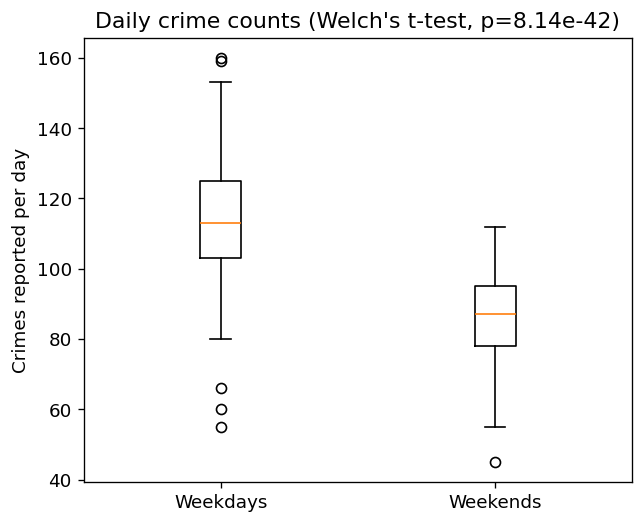

In [11]:
daily = df.groupby(df["report_date"].dt.normalize()).size()
weekend = daily[daily.index.dayofweek >= 5]
weekday = daily[daily.index.dayofweek < 5]

t_stat, p_t = stats.ttest_ind(weekday, weekend, equal_var=False)
print(f"Welch's t = {t_stat:.3f}, p = {p_t:.3g}")
print(f"Weekdays (n={len(weekday)}): mean={weekday.mean():.1f}, std={weekday.std():.1f}")
print(f"Weekends (n={len(weekend)}): mean={weekend.mean():.1f}, std={weekend.std():.1f}")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.boxplot([weekday, weekend], tick_labels=["Weekdays", "Weekends"])
ax.set_ylabel("Crimes reported per day")
ax.set_title(f"Daily crime counts (Welch's t-test, p={p_t:.3g})")
plt.tight_layout()
fig.savefig("figures/weekday_weekend.png", dpi=150)
plt.show()

**Result:** t = 16.68, p < 0.001. Weekdays average 113.4 reported crimes per day (std 16.4) versus 86.2 on weekends (std 13.0), about 27 fewer per day, or 24% lower. A likely explanation is that many reports are property crimes discovered or filed during the working week, and reporting itself follows business-day patterns, so this reflects *reported* crime, not necessarily when crimes occur.

### 4.5 Pearson correlation: how fast cases close vs. how many get cleared, by ZIP code

**Hypothesis:** ZIP codes where cleared cases are closed out faster (lower median days to clearance) also have higher overall clearance rates, i.e. quick follow-up goes together with solving more cases. Each ZIP code with at least 20 cleared cases is one observation; we report the Pearson correlation and show the scatterplot with a fitted line.

ZIP codes analysed: 34
Mean clearance rate = 0.159 (std 0.077); mean median-days-to-clear = 8.0 (std 4.0)
Pearson r = -0.340, p = 0.0492, n = 34


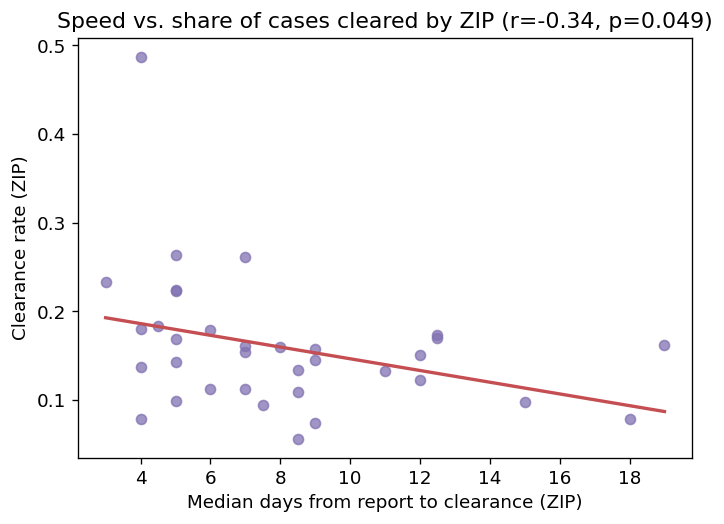

In [12]:
zip_time = (done.dropna(subset=["zipcode"]).groupby("zipcode")
            .agg(median_days=("days_to_clear", "median"), n_cleared=("days_to_clear", "size")))
zip_time = zip_time[zip_time["n_cleared"] >= 20]
zip_time["clearance_rate"] = cl.dropna(subset=["zipcode"]).groupby("zipcode")["cleared"].mean()

print(f"ZIP codes analysed: {len(zip_time)}")
print(f"Mean clearance rate = {zip_time['clearance_rate'].mean():.3f} (std {zip_time['clearance_rate'].std():.3f});"
      f" mean median-days-to-clear = {zip_time['median_days'].mean():.1f} (std {zip_time['median_days'].std():.1f})")
r_p, p_p = stats.pearsonr(zip_time["median_days"], zip_time["clearance_rate"])
print(f"Pearson r = {r_p:.3f}, p = {p_p:.4f}, n = {len(zip_time)}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(zip_time["median_days"], zip_time["clearance_rate"], alpha=0.75, color="#8172B2")
m, b = np.polyfit(zip_time["median_days"], zip_time["clearance_rate"], 1)
xs = np.linspace(zip_time["median_days"].min(), zip_time["median_days"].max(), 50)
ax.plot(xs, m * xs + b, color="#C44E52", linewidth=2)
ax.set_xlabel("Median days from report to clearance (ZIP)")
ax.set_ylabel("Clearance rate (ZIP)")
ax.set_title(f"Speed vs. share of cases cleared by ZIP (r={r_p:.2f}, p={p_p:.3f})")
plt.tight_layout()
fig.savefig("figures/speed_vs_clear.png", dpi=150)
plt.show()

**Result:** Pearson r = -0.34, p = 0.049 (n = 34 ZIP codes). This is a moderate, borderline-significant *negative* correlation: ZIP codes where cleared cases are closed out faster tend to clear a larger share of their cases overall. The relationship is far from deterministic (r&sup2; &asymp; 12% of the variance), so speed explains only a small part of why some areas solve more cases, and being borderline (p just under 0.05, one of several tests run) it should be treated as suggestive. It does not show that speed *causes* higher clearance; both may reflect crime mix or staffing.

## 5. Summary and limitations

**Summary.** In Austin's 2015 police records, *what kind* of crime it is matters most for whether it is solved: murder and aggravated assault are cleared 62–94% of the time, but burglary and theft, which make up most reported crime, are cleared only 11–14% of the time (overall 17%). Districts differ modestly (10–21%), arrests happen much faster than exception clearances (median 5 vs. 21 days), ZIP codes that close cases faster tend to clear more of them (r = -0.34), and about 27 fewer crimes are reported per day on weekends than on weekdays. For a city planner or police-oversight analyst, the takeaway is that the low overall clearance rate is driven mostly by high-volume property crimes, so district-to-district comparisons should be adjusted for crime mix.

**Limitations.**
1. *No demographic or housing data*: the Kaggle dataset only contains crime records, so we cannot relate crime to neighborhood income, poverty or housing.
2. *Reported, not actual, crime*: all counts reflect crimes that were reported and recorded.
3. *`clearance_date` ambiguity*: it is filled in for many uncleared cases, so timing results (4.3) should be read cautiously.
4. *Association, not causation*: e.g. district differences may reflect crime mix or staffing, not police effectiveness.
5. *One year, and no time of day*: 2014 uses different offense labels so was excluded, and report dates have no hour information.
6. *Multiple tests*: five tests were run at &alpha; = 0.05; the borderline ZIP-level Pearson result in 4.5 in particular could be chance.